In [36]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from obasho_mlmodel_utils import *
from preproclc import *
from gauss_noise_utils import *
#from batman_utils import *

n=2
generator = HybridConvNet(n=n)
#generator.load_state_dict(torch.load(f'models/morg4{n}.pth',weights_only=True))
#lc=torch.tensor(np.load('/DATA/s23103/seti/dst/LC10/weird_test_shapes_solidLC.npy'))
generator.load_state_dict(torch.load(f'morg4{n}.pth',weights_only=True, map_location='cpu'))

<All keys matched successfully>

In [58]:

# Define ranges for the 3 parameters
rsrp_values = [2, 5, 10, 15, 20, 25]            # integers
lda_values  = [0.2, 0.4, 0.6, 0.8, 0.1, 0.12]      # floats
ldb_values  = [0.06, 0.10, 0.14, 0.18, 0.22, 0.24]           # floats
snr_values = [1000,800,600,400,200,100]

# rsrp_values = [2] 
# lda_values  = [0.2]      # floats
# ldb_values  = [0.06]           # floats
# snr_values = [1000]

ltcrvs_sets_noisy = []
# Loop through all combinations
for rsrp in rsrp_values:
    print(f"load ltcrv file with radius ratio {rsrp}")
    for lda in lda_values:
        for ldb in ldb_values:
            for snr in snr_values:
                #print(f"load ltcrv file with {rsrp}, {lda}, {ldb}")
                filepath = f"shapes_lcs_test/set1/test_shapes_noncirc_circ_both_{rsrp}_{lda}_{ldb}LC_processed.npy"
                ltcrvs = np.load(filepath)
                #ltcrvs_noisy = add_gaussian_noise(ltcrvs, snr, seed = 60)
                ltcrvs_noisy, sigma = sample_rowwise_gaussian_noise(ltcrvs, snr=snr, seed=42, sigmas_precal= None)
                #ltcrvs_sets_noisy.append(ltcrvs_noisy)

                outfile1 = f"shapes_lcs_test/set1/test_shapes_noncirc_circ_both_{rsrp}_{lda}_{ldb}LC_processed_snr{snr}.npy"
                outfile1_sigma = f"shapes_lcs_test/set1/test_shapes_noncirc_circ_both_{rsrp}_{lda}_{ldb}LC_processed_snr{snr}_sigmavals.npy"
                np.save(outfile1,ltcrvs_noisy)
                np.save(outfile1_sigma,sigma )
                
                lc_filename = outfile1#f"shapes_lcs_test/test_shapes_noncirc_circ_{rsrp}_{lda}_{ldb}LC_processed_snr{snr}.npy"
                out_filename = f"shapes_lcs_test/set1/test_shapes_noncirc_circ_both_{rsrp}_{lda}_{ldb}LC_processed_snr{snr}_PredctdShape.npy"

                lc=torch.tensor(np.load(lc_filename))
                out=[]
                #print(lc.shape)
                generator.eval()
                for i in range(lc.shape[0]):
                    #out.append(generator(lc[i].squeeze() ).squeeze().detach().cpu())
                    out.append(generator(lc[i].unsqueeze(0).float()).squeeze().detach().cpu())
                np.save(out_filename,torch.stack(out, dim=0).numpy())
                



load ltcrv file with radius ratio 2
load ltcrv file with radius ratio 5
load ltcrv file with radius ratio 10
load ltcrv file with radius ratio 15
load ltcrv file with radius ratio 20
load ltcrv file with radius ratio 25


/tmp/ipykernel_3847708/332558505.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


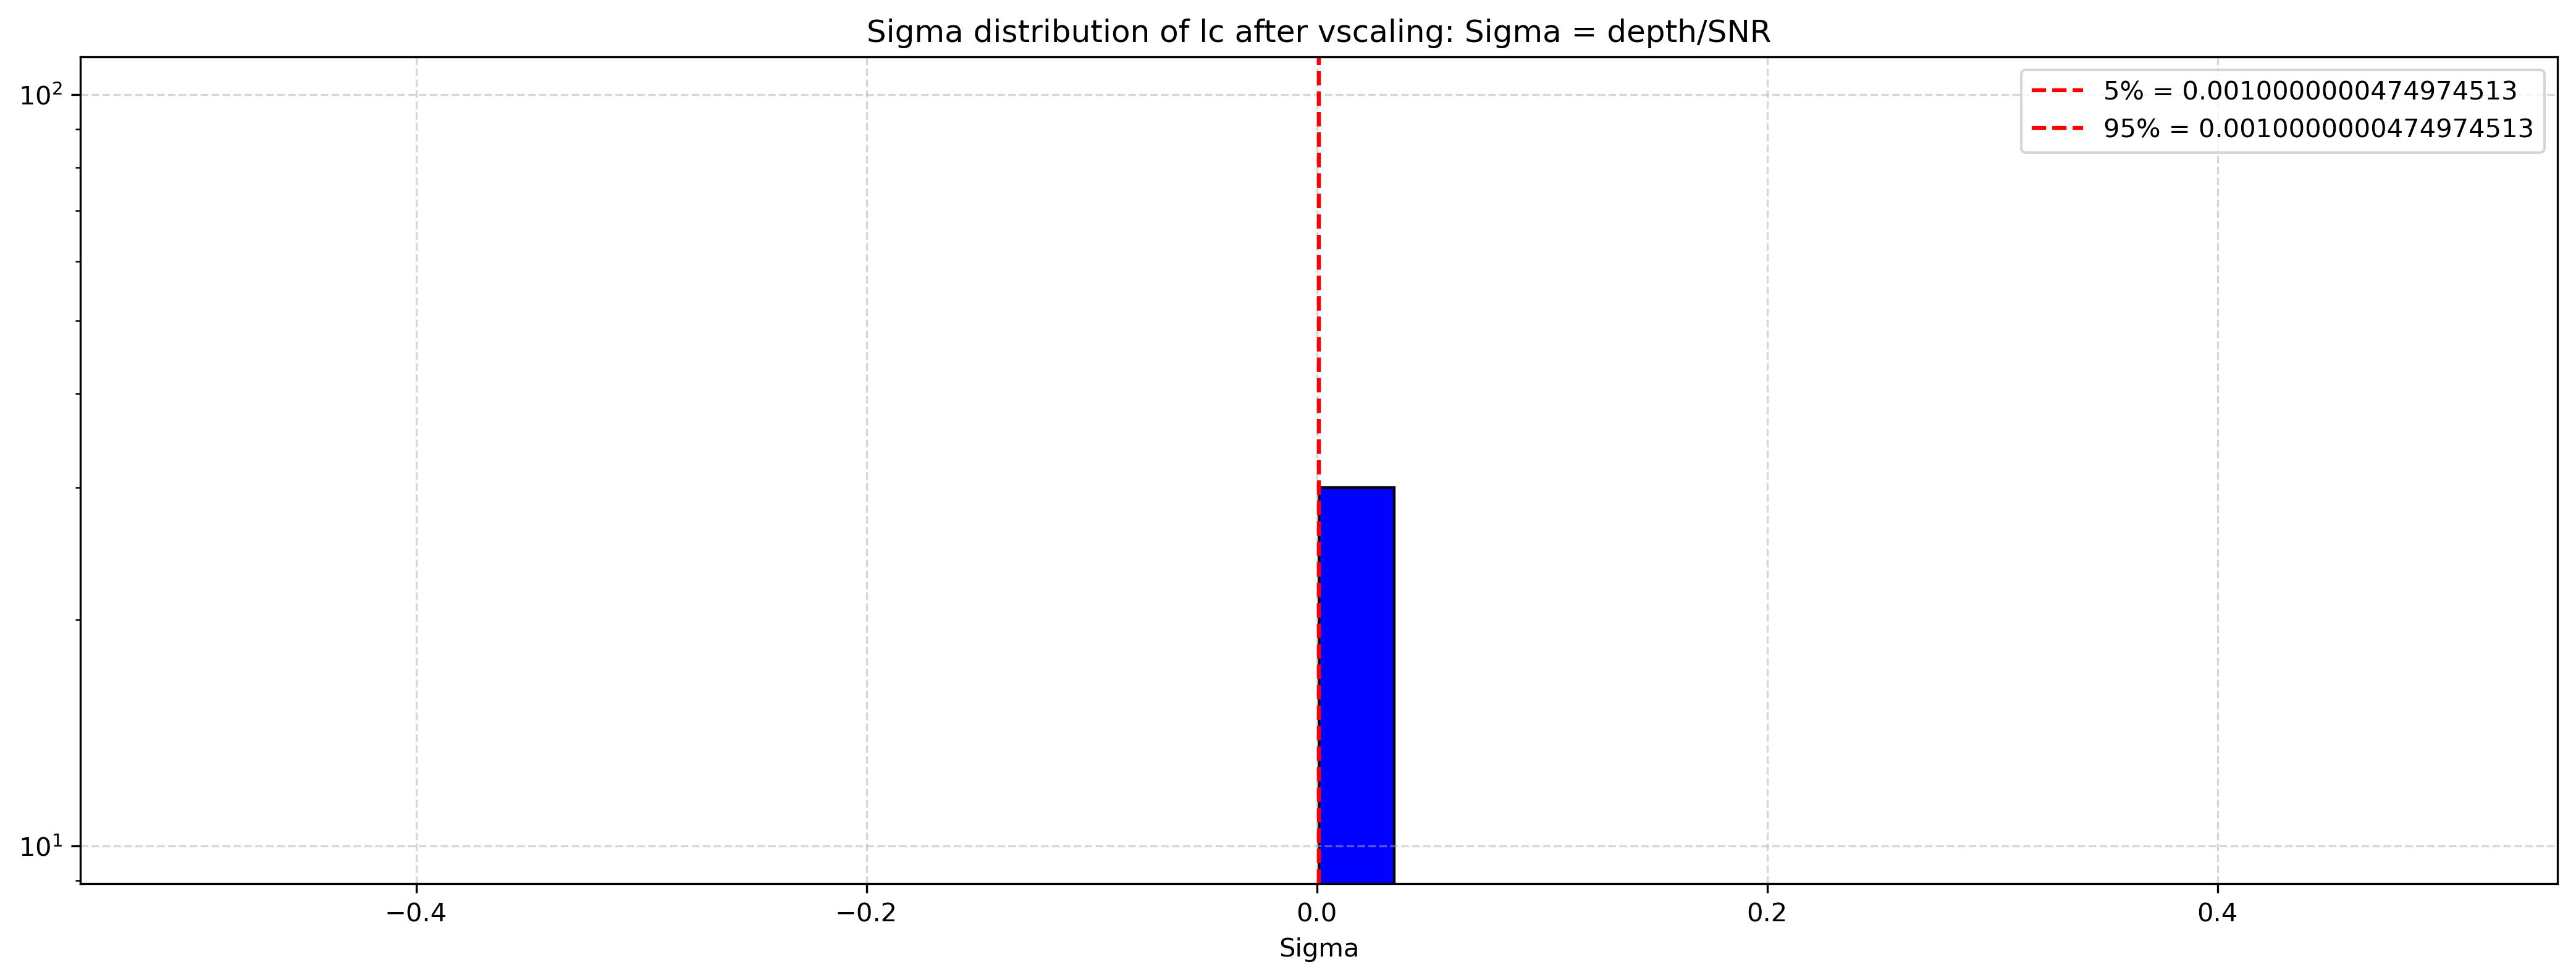

In [62]:
rsrp = rsrp_values[0]
ldb = ldb_values[0]
ldb = ldb_values[0]
snr = snr_values[0]
sigma = np.load(f"shapes_lcs_test/set1/test_shapes_noncirc_circ_both_{rsrp}_{lda}_{ldb}LC_processed_snr{snr}_sigmavals.npy")
#print(sigma)
fontsize = 8
fig, ax = plt.subplots(2, 1, figsize=(14, 10), dpi=300)

ax[0].hist(sigma, bins=30,density=True,facecolor='b',edgecolor='black')
ax[0].axvline(np.nanpercentile(sigma, 5),color='r',ls='--',label=f"5% = {np.round(np.nanpercentile(sigma, 5),8)}")
ax[0].axvline(np.nanpercentile(sigma, 95),color='r',ls='--',label=f"95% = {np.round(np.nanpercentile(sigma, 95),8)}")
ax[0].set_title(rf"Sigma distribution of lc after vscaling: Sigma = depth/SNR")
ax[0].set_xlabel("Sigma")
ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].set_yscale('log')
#ax[0,1].set_xscale('log')
ax[0].legend()

ax[1].set_visible(False)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_3847708/2339404625.py:41: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


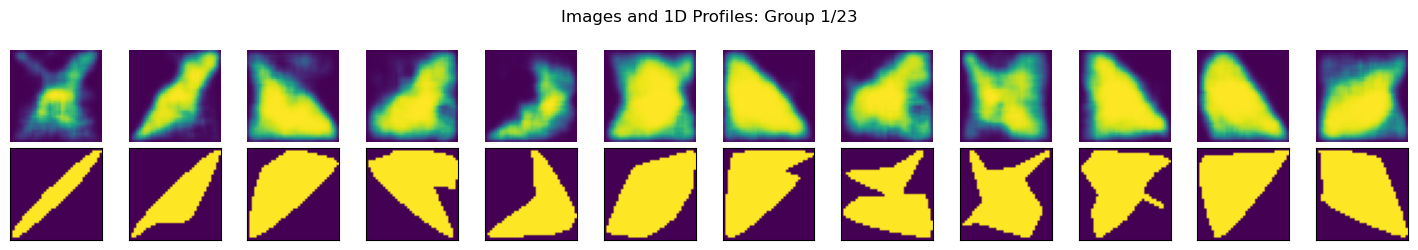

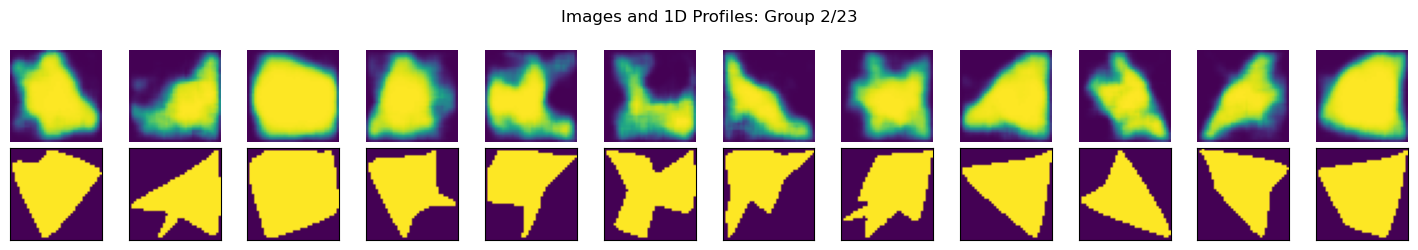

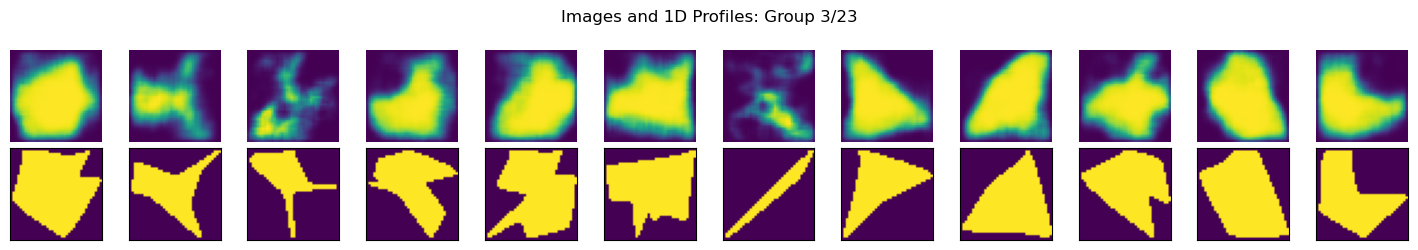

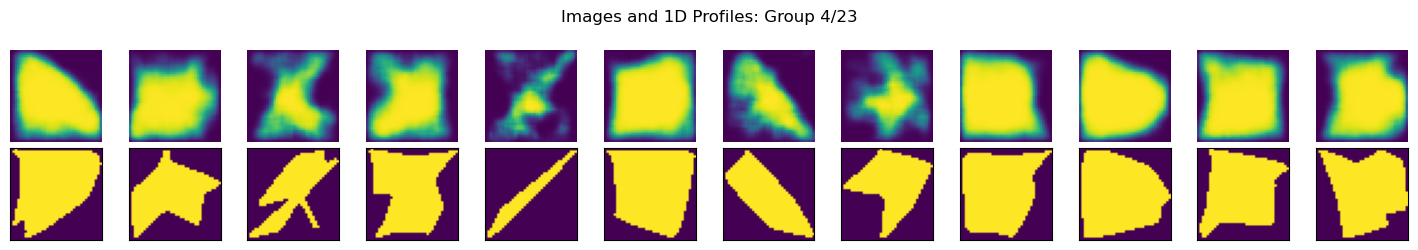

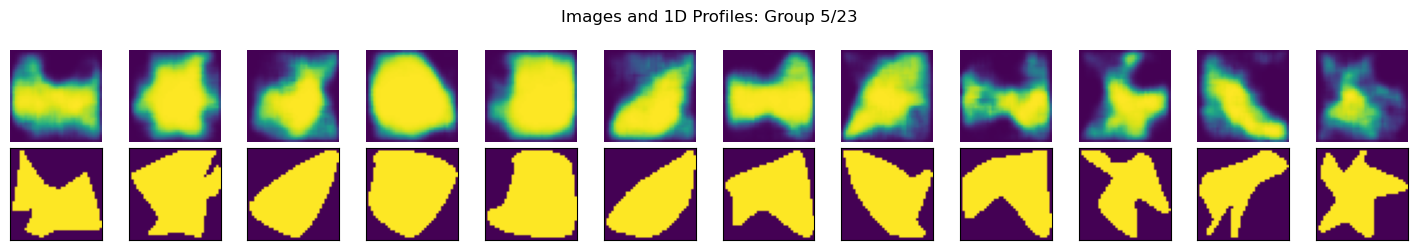

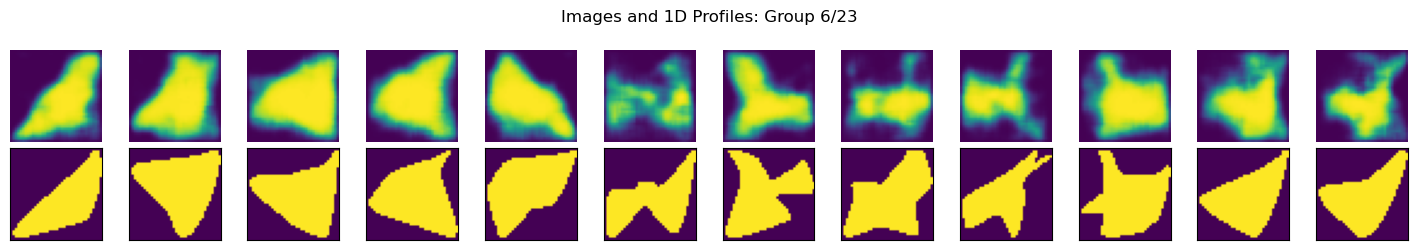

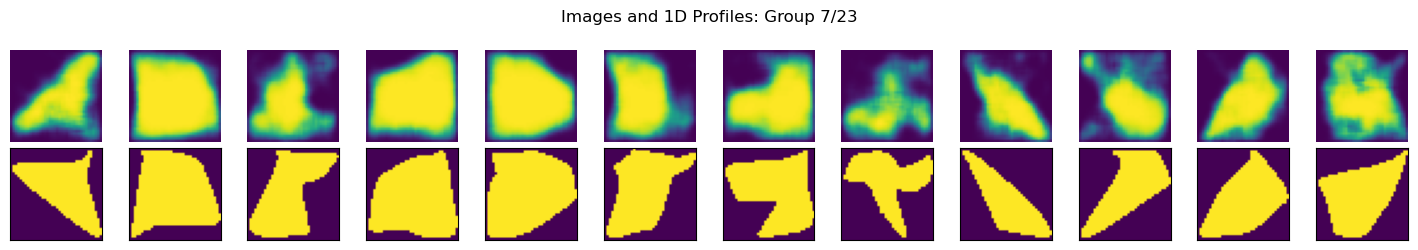

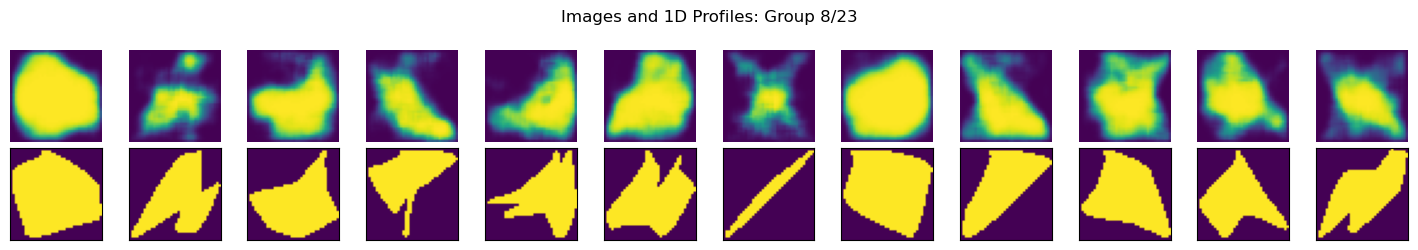

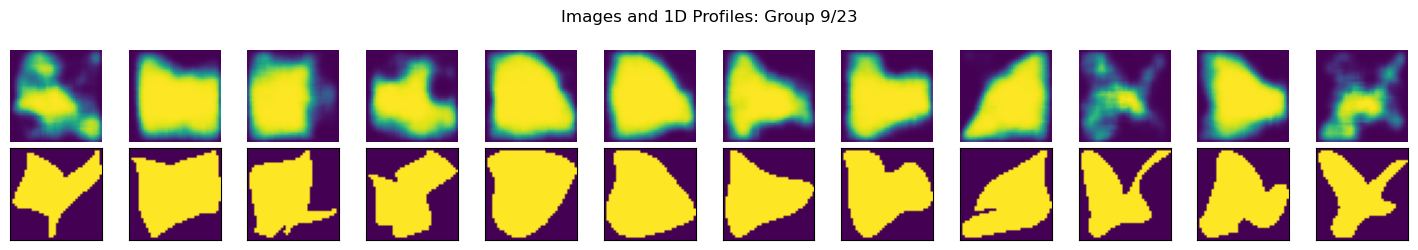

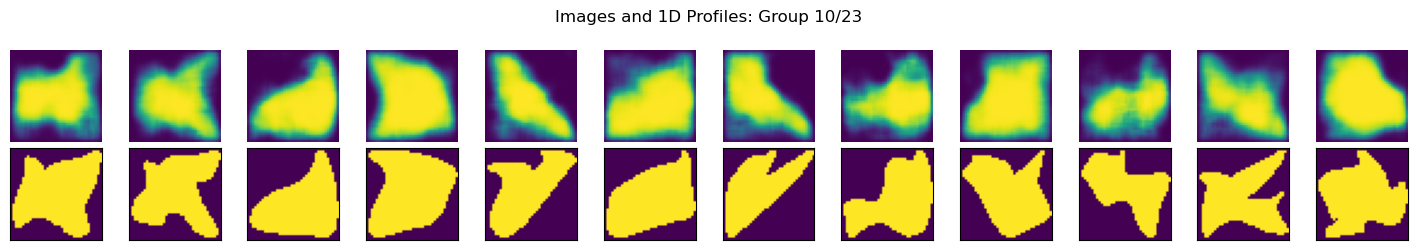

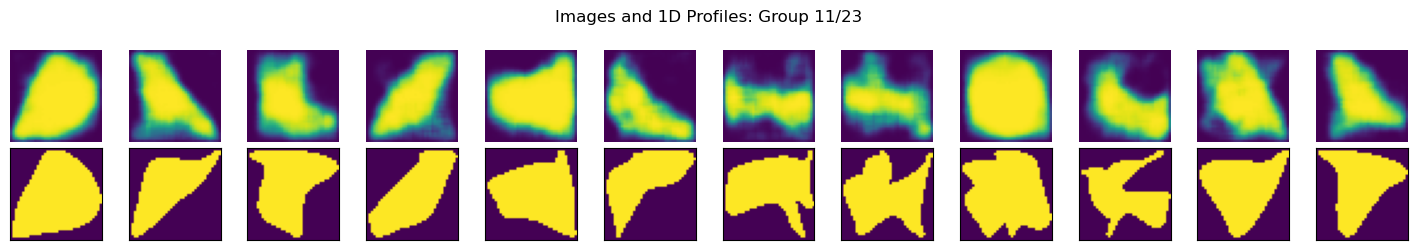

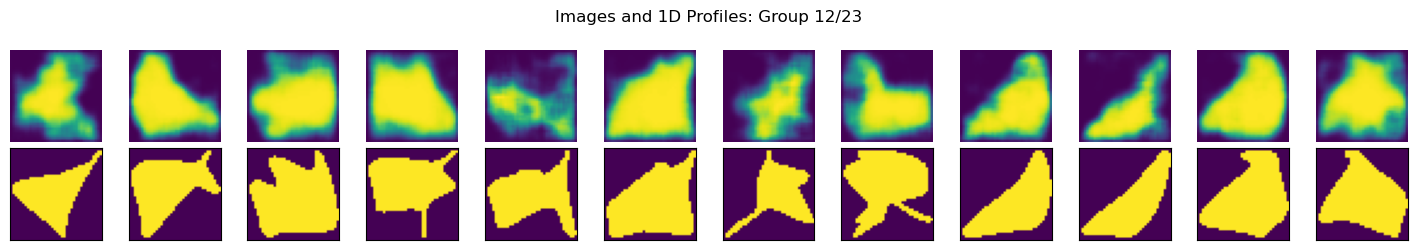

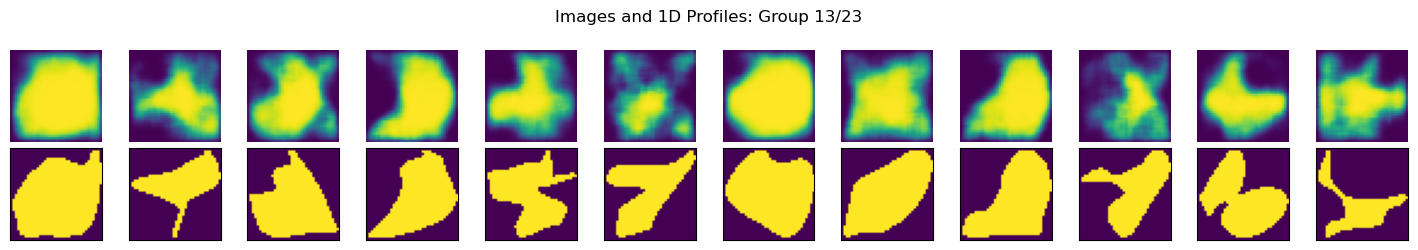

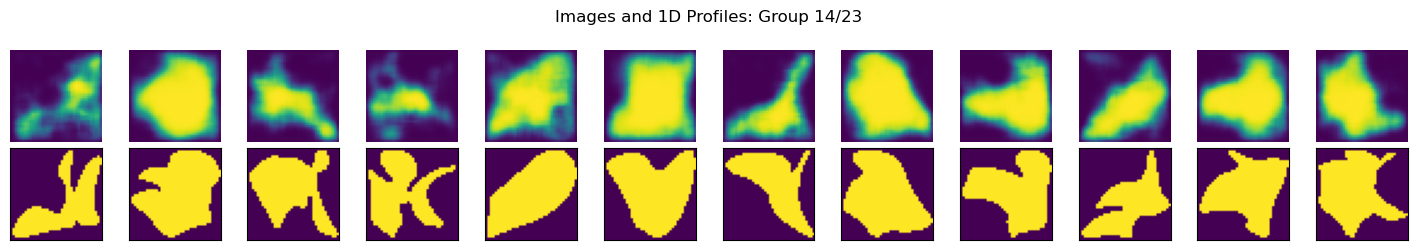

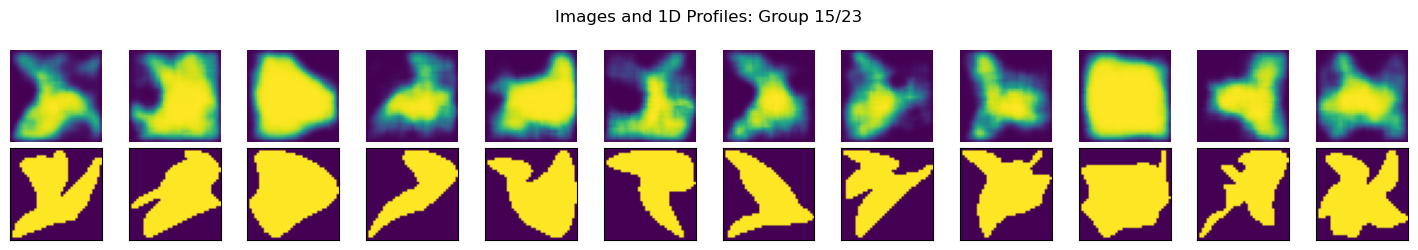

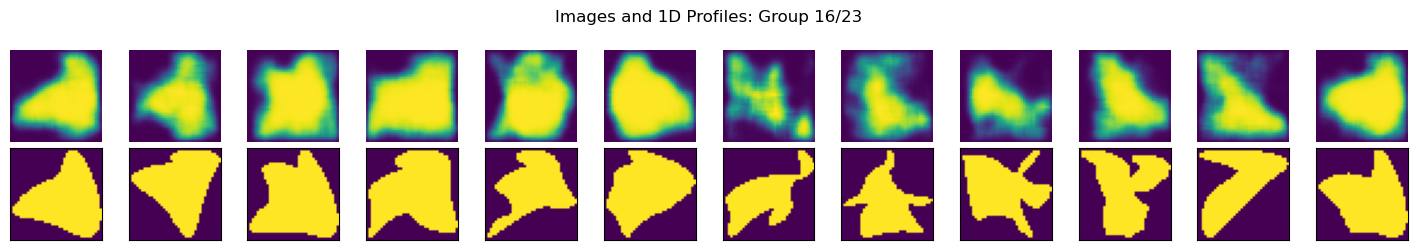

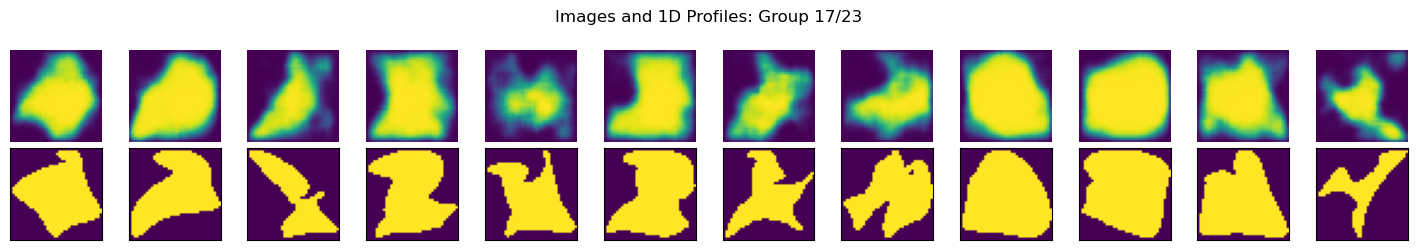

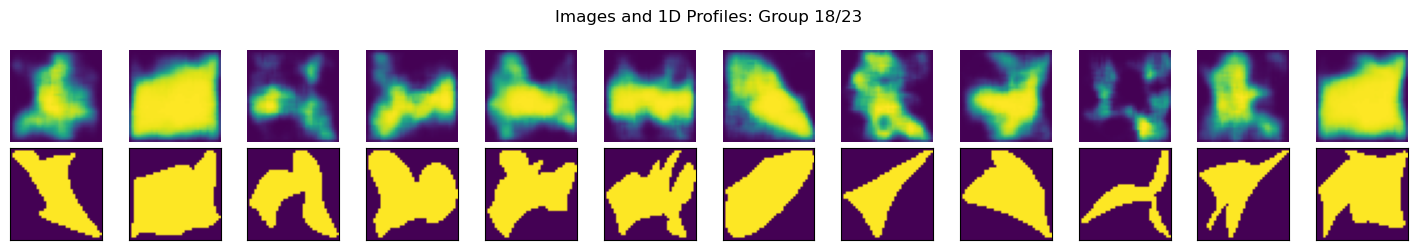

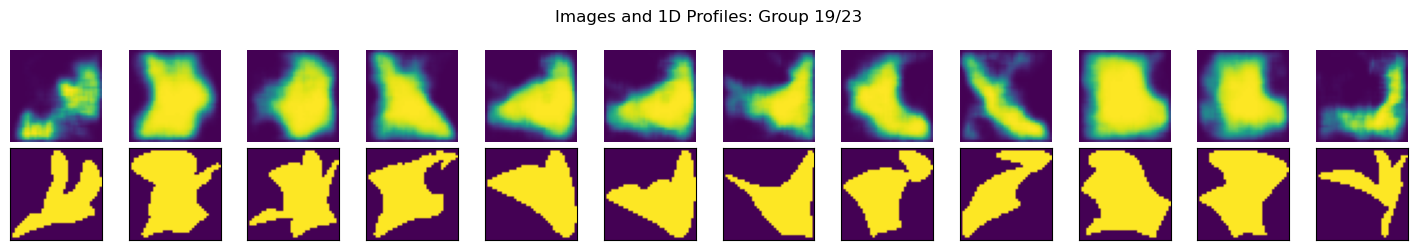

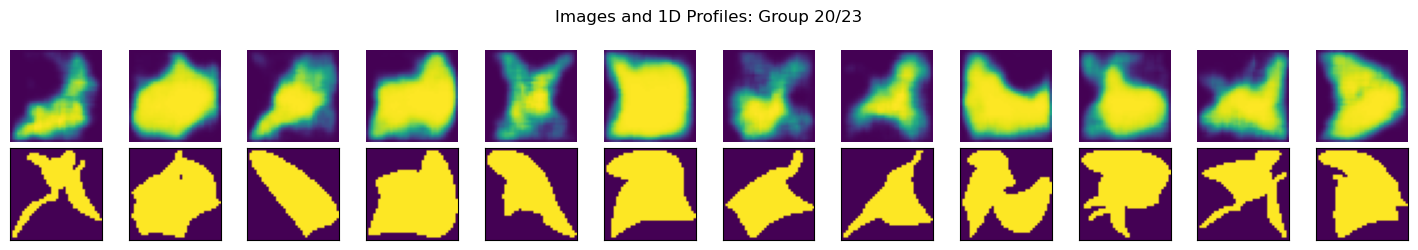

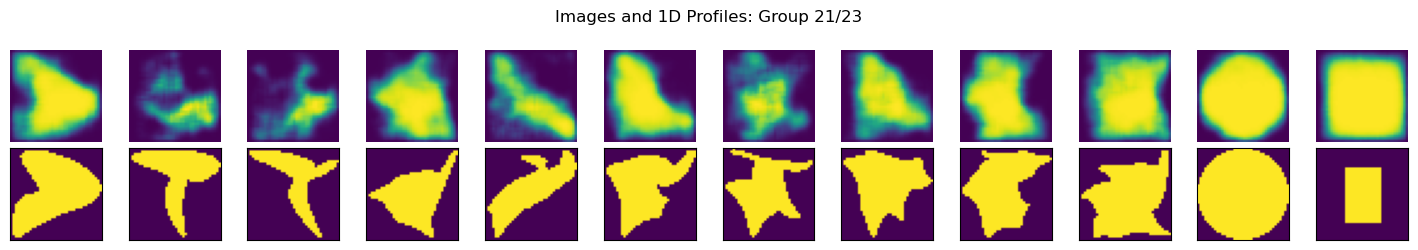

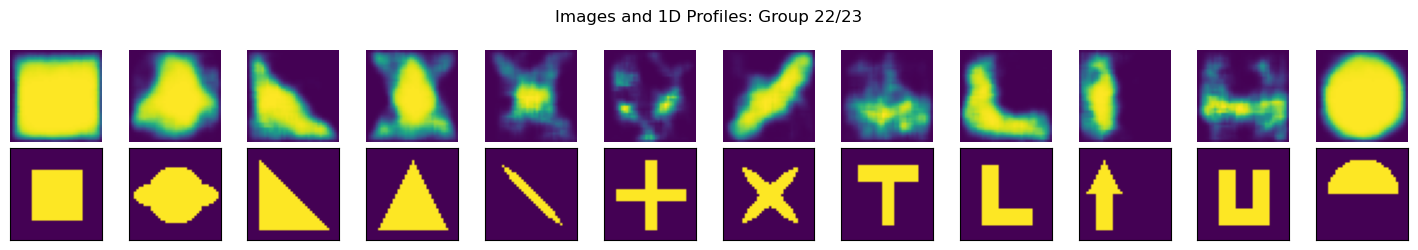

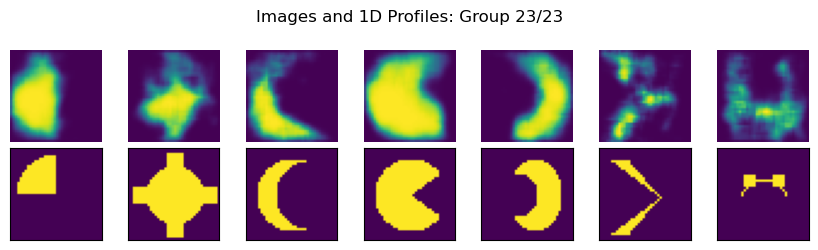

In [63]:

rsrp = rsrp_values[0]
ldb = ldb_values[0]
ldb = ldb_values[0]
snr = snr_values[0]

out_filename = f"shapes_lcs_test/set1/test_shapes_noncirc_circ_both_{rsrp}_{lda}_{ldb}LC_processed_snr{snr}_PredctdShape.npy"#f"shapes_lcs_test/set1/test_set1_{rsrp}_{lda}_{ldb}_lcs_processed_snr{snr}_PredctdShape.npy"
org_shapes_file = "shapes_lcs_test/set1/test_shapes_noncirc_circ_both_shapes.npy"

predicted_shape = np.load(out_filename)
org_shapes = np.load(org_shapes_file)

images = predicted_shape
predictions = org_shapes


n_total = images.shape[0]
n_cols = 12                               # number of images per row
n_groups = int(np.ceil(n_total / n_cols))  # number of full groups

for group in range(n_groups):
    start = group * n_cols
    end = min(start + n_cols, n_total)
    count = end - start

    fig, axes = plt.subplots(2, count, figsize=(count * 1.2, 2.5), constrained_layout=True)

    for i in range(count):
        # Plot image
        ax_img = axes[0, i] if count > 1 else axes[0]
        ax_img.imshow(images[start + i], cmap='viridis')
        #ax_img.set_title(f"{kepnames[start + i]}\n$R_p/R_s$: {rp_rs_ratio[start + i]:.2f}\n$snr$: {snr[start + i]:.2f}", fontsize=8)
        ax_img.axis('off')

        # Plot 1D profile
        ax_prof = axes[1, i] if count > 1 else axes[1]
        ax_prof.imshow(predictions[start + i], cmap='viridis')
        ax_prof.set_xticks([])
        ax_prof.set_yticks([])

    plt.suptitle(f"Images and 1D Profiles: Group {group+1}/{n_groups}", fontsize=12)
    plt.tight_layout()
    #plt.savefig('figures/circle_shapes_predictions_torch.pdf')
    plt.show()